**Launch this notebook:**

colab todo<!-- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/access-UK-radar-data/blob/main/notebooks/CEH-GEAR-1hr/gear_netcdf_python.ipynb) -->
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Thomasjkeel/access-UK-radar-data/HEAD)

(CTRL + Click to open in a new tab)

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/access-UK-radar-data/blob/main/README.md#How-to-run-these-notebooks).

---

**Setup**
If you would like to install required packages, uncomment and run cell below...

In [ ]:
# %%capture
# !pip install xarray[io] rioxarray rasterio matplotlib numpy geopandas

In [35]:
# Python standard libraries
import gzip
import io
import os
import tarfile

# 3rd party libraries
import pandas as pd
import rioxarray
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# local files
import nimrod

# Introduction
In this short tutorial, we will go through how to load in and subset radar data from the following source:
* Met Office Rain Radar Data from the NIMROD System from the CEDA Archive ([link](https://catalogue.ceda.ac.uk/uuid/82adec1f896af6169112d09cc1174499/?q=&results_per_page=20&sort_by=title_desc&objects_related_to_uuid=82adec1f896af6169112d09cc1174499&page=3))

We will assume that you have gone and downloaded some NIMROD data from the CEDA Archive e.g. this file: [1 km Resolution UK Composite Rainfall Data from the Met Office Nimrod System](https://data.ceda.ac.uk/badc/ukmo-nimrod/data/composite/uk-1km).

Let's now imagine that you have stored that data in the local folder: "NIMROD_UK_composite_1km". For now, that folder contains a single day of data for this example, on the 9th October 2023.

The section will cover:  
1. Extract NIMROD data to ascii format   
2. Look at a single 5 min time step
3. Look at entire day of 5 min time steps
4. Plot data with Cartopy
5. Resample data to hourly
6. Subset data to river catchment boundary


We will use [xarray](https://docs.xarray.dev/en/stable/index.html) to read in the NIMROD data.

## 1. Extract NIMROD data to ascii format 
INTRO

The following 2 variables store the path to the NIMROD data and the format of the compressed archives.
Change folder path & gzip_name as appropriate below.

> **Note:** We are assuming that the you have downloaded 1km-composite data

In [2]:
PATH_TO_NIMROD_FOLDER =  "NIMROD_UK_composite_1km/"

In [3]:
GZIP_DATA_NAME = "metoffice-c-band-rain-radar_uk_{0}_1km-composite.dat.gz.tar"

So we can read the data in xarray format, we can extract the NIMROD data format into an ascii file

We'll save the output ascii files to the location "formatted_NIMROD_data"...

In [4]:
OUTPUT_FOLDER = "formatted_NIMROD_data/"

In [5]:
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER, exist_ok=False)

Secondly, we'll work with the single day for now, the example data from the 9th October 2023.

In [6]:
all_dates_to_process = ["20231009"] # This list only contains one date for now

In [7]:
# ~10 mins per file and each are 3 GB (timings are resource-dependent)
OVERWRITE_FILES = True
for date_to_process in all_dates_to_process:
    tar_path = os.path.join(
        PATH_TO_NIMROD_FOLDER,
        GZIP_DATA_NAME.format(date_to_process)
    )

    # Create folder for this date
    output_dir = os.path.join(OUTPUT_FOLDER, str(date_to_process))
    if os.path.exists(output_dir):
        print(output_dir, "already exists")
        if not OVERWRITE_FILES: 
            continue
        else:
            print("Overwriting...")
    else:
        os.makedirs(output_dir, exist_ok=False)

    with tarfile.open(tar_path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".dat.gz"):
                print(f"Extracting: {member.name}...")
                with tar.extractfile(member) as gz_stream:
                    with gzip.GzipFile(fileobj=gz_stream) as dat_stream:
                        dat_bytes = dat_stream.read()
                        nimrod_data = nimrod.Nimrod(io.BytesIO(dat_bytes))

                        base_name = os.path.basename(member.name[:-7])  # remove .dat.gz
                        out_path = os.path.join(output_dir, f"{base_name}.asc")

                        with open(out_path, "w") as out_file:
                            nimrod_data.extract_asc(out_file)

formatted_NIMROD_data/20231009 already exists
Overwriting...
Extracting: metoffice-c-band-rain-radar_uk_202310092345_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092350_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092355_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092335_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092340_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092325_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092330_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092315_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092320_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092305_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092310_1km-composite.dat.gz...
Extracting: metoffice-c-band-rain-radar_uk_202310092255_1km

## 2. Read one time step

In [7]:
example_nimrod_raster = xr.open_dataarray(
    os.path.join(OUTPUT_FOLDER, all_dates_to_process[0], "metoffice-c-band-rain-radar_uk_202310092045_1km-composite.asc")
)

In [8]:
example_nimrod_raster.load()

<xarray.DataArray 'band_data' (band: 1, y: 2175, x: 1725)> Size: 15MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 2175, 1725), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
  * x            (x) float64 14kB -4.045e+05 -4.035e+05 ... 1.318e+06 1.32e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point

## 3. Load an entire day of 5-min time steps
Firstly, let's lazy load the data. That is, not load it into memory just yet

In [9]:
DATE_TO_USE = all_dates_to_process[0]
print(DATE_TO_USE)

20231009


In [ ]:
one_day_nimrod = xr.open_mfdataset(os.path.join(OUTPUT_FOLDER, DATE_TO_USE, "*"), combine='nested', concat_dim='time', engine='rasterio')

In [17]:
# re-chunk
one_day_nimrod = one_day_nimrod.chunk({
    "time": 24,
    "band": 1,
    "y": 512,
    "x": 512,
})

In [19]:
one_day_nimrod = one_day_nimrod.rename({'band_data': 'rainfall_rate'})
one_day_nimrod['rainfall_rate']['units'] = "mm/hr"

In [20]:
one_day_nimrod_clip = one_day_nimrod.sel(x=slice(None, 900_000), y=slice(1_250_000, -400_000))

In [21]:
dates = pd.date_range(
    start=f"{DATE_TO_USE[:4]}-{DATE_TO_USE[4:6]}-{DATE_TO_USE[6:8]} 00:00",
    end=f"{DATE_TO_USE[:4]}-{DATE_TO_USE[4:6]}-{DATE_TO_USE[6:8]} 23:55",
    freq="5min"
)

one_day_nimrod_clip['time'] = dates

# data was scaled up by 32
one_day_nimrod_clip['rainfall_rate'] = one_day_nimrod_clip['rainfall_rate'] / 32

In [22]:
one_day_nimrod_clip

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 288, band: 1, y: 1650, x: 1305)
Coordinates:
  * time           (time) datetime64[us] 2kB 2023-10-09 ... 2023-10-09T23:55:00
  * band           (band) int64 8B 1
  * y              (y) float64 13kB 1.25e+06 1.248e+06 ... -3.985e+05 -3.995e+05
  * x              (x) float64 10kB -4.045e+05 -4.035e+05 ... 8.995e+05
    spatial_ref    int64 8B 0
Data variables:
    rainfall_rate  (time, band, y, x) float32 2GB dask.array<chunksize=(24, 1, 212, 512), meta=np.ndarray>

In [23]:
%%time
# Takes 8-10 mins (timing is resource-dependent)
one_day_nimrod_clip.load()

CPU times: user 13min 6s, sys: 48.1 s, total: 13min 54s
Wall time: 12min 30s


<xarray.Dataset> Size: 2GB
Dimensions:        (time: 288, band: 1, y: 1650, x: 1305)
Coordinates:
  * time           (time) datetime64[us] 2kB 2023-10-09 ... 2023-10-09T23:55:00
  * band           (band) int64 8B 1
  * y              (y) float64 13kB 1.25e+06 1.248e+06 ... -3.985e+05 -3.995e+05
  * x              (x) float64 10kB -4.045e+05 -4.035e+05 ... 8.995e+05
    spatial_ref    int64 8B 0
Data variables:
    rainfall_rate  (time, band, y, x) float32 2GB nan nan nan ... nan nan nan

## 4. plot data

In [27]:
bng = ccrs.TransverseMercator(
    central_longitude=-2.0,  ## +lon_0
    central_latitude=49.0,      # +lat_0
    scale_factor=0.999601,      # +k
    false_easting=400000.0,     # +x_0
    false_northing=-100000.0,   # +y_0
    globe=ccrs.Globe(ellipse='airy')  # +ellps=airy
)


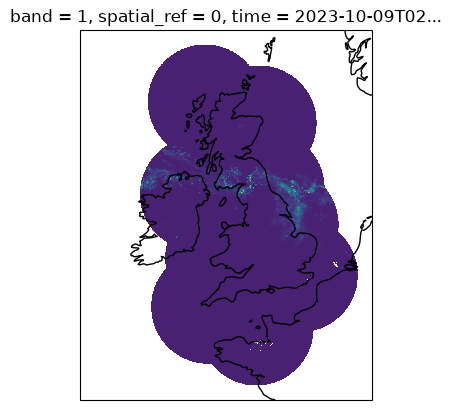

In [33]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
one_day_nimrod_clip.isel(time=30)['rainfall_rate'].plot(vmin=-1, vmax=10, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines();

## 5. Resample to hourly

In [31]:
one_day_nimrod_clip_hourly = one_day_nimrod_clip.resample(
    time="1h",
    closed="left"
).mean()

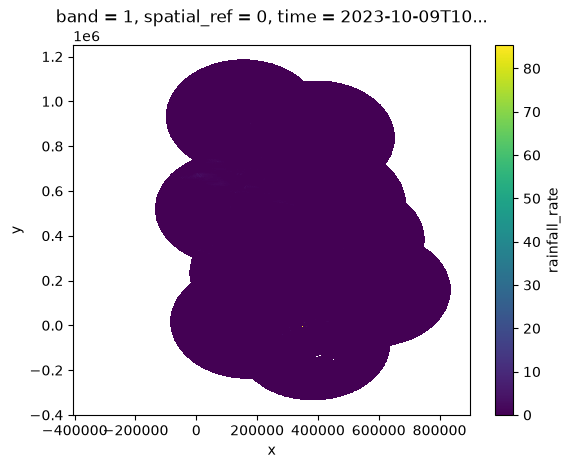

In [32]:
one_day_nimrod_clip_hourly.isel(time=10)['rainfall_rate'].plot()

In [ ]:
# one_day_nimrod_clip_hourly.to_netcdf(f'nimrod_data/nimrod_hourly_resample_{DATE_TO_USE}.nc')

## 6. Subset to a National River Flow Archive (NRFA) catchment

In [34]:
def make_region_hght_clip(region_shp, hght_data):
    """Clip region by height raster"""
    region_clip = hght_data.rio.clip(
        region_shp.geometry.values, region_shp.crs, drop=False, invert=False
    )
    return region_clip


def binarize_hght_clip(region_data):
    """
    Make binary mask of clipped region data data
    """
    return region_data / region_data.where(region_data > 0)


def mask_region_rainfall(rainfall_data, region_mask):
    """
    Mask region by binary height raster
    """
    return rainfall_data * binarize_hght_clip(region_mask).data


In [40]:
CATCHMENT_BUFFER = 1000 # metres

In [ ]:
# Read in catchment boundary
nrfa_shp = gpd.read_file("../spatial_data/NRFA_catchments/nrfa_54014/NRFA_catchments.shp")
print(nrfa_shp.bounds)

       minx      miny      maxx      maxy
0  281525.0  275075.0  320725.0  303925.0


<Axes: >

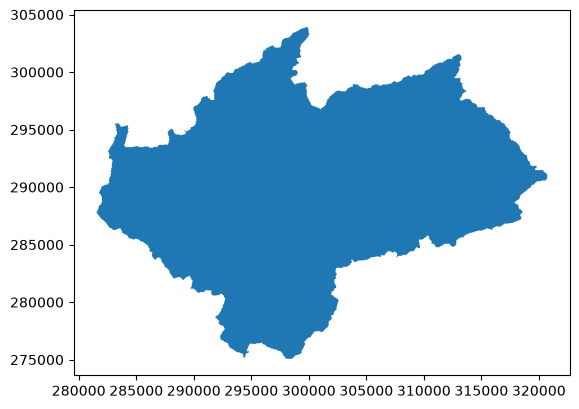

In [49]:
nrfa_shp.plot()

*NOTE: your data may not have a descending y-axis. Please check your data*

In [44]:
# Subset to bounds of given catchment 
catchment_nimrod_hourly = one_day_nimrod_clip_hourly.sel(
    x=slice(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER),
    y=slice(nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER, nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER), # has to be reversed as y coordinates is descending
)
catchment_nimrod_hourly = catchment_nimrod_hourly.sortby("y")  # flip y coordinates


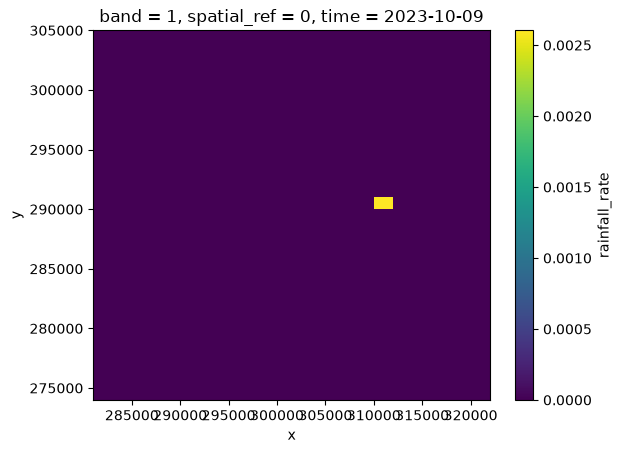

In [48]:
catchment_nimrod_hourly.isel(time=0)['rainfall_rate'].plot()

In [ ]:


    # 3. Make catchment mask
    catchment_mask = make_region_hght_clip(nrfa_shp, uk_hght)
    catchment_mask = catchment_mask.isel(y=slice(None, None, -1)) # flip y coords
    catchment_mask = catchment_mask.sel(
        x=slice(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER),
        y=slice(nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER), 
    )

In [ ]:

    # 3.1 Plot (can remove)
    # fig, ax = plt.subplots(1)
    # catchment_mask.plot(ax=ax, alpha=.7, add_colorbar=False)
    # ax.set_xlim(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER);
    # ax.set_ylim(nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER);
    # plt.show()


In [ ]:

    # 4. Mask rainfall based on catchment mask
    catchment_rainfall = mask_region_rainfall(catchment_gear_hourly, catchment_mask)